In [1]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 24.5 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
from matplotlib.colors import LinearSegmentedColormap
import os
import scipy.stats as stats

In [2]:
sam_mg = SAM()
sam_mg.load_data('../../Active_SAM_joined/SAM_Allen_Institute_allhypo_01272026.h5ad')

In [6]:
with open('../../parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [4]:
#update columns to match your organisms
plt_df_saturn = pd.DataFrame(index = [i for i in sam_mg.adata.obs['subclass_id_label'].unique() if parent_dict[parent_dict[i]] == 'hypo'],
                      columns = ['mg','mo','cj','ac','xt','dr'])
plt_df_samap = pd.DataFrame(index = [i for i in sam_mg.adata.obs['subclass_id_label'].unique() if parent_dict[parent_dict[i]] == 'hypo'],
                      columns = ['mg','mo','cj','ac','xt','dr'])
plt_df_NT = pd.DataFrame(index = [i for i in sam_mg.adata.obs['subclass_id_label'].unique() if parent_dict[parent_dict[i]] == 'hypo'],
                      columns = ['mg','mo','cj','ac','xt','dr'])

In [34]:
#rerun for all organisms that you are including
fn = '../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_03122025.h5ad'

In [35]:
sam = SAM()
sam.load_data(fn)

In [36]:
org = 'mo'

In [37]:
#SATURN relabels
lsaturn_m = pd.read_csv('../../SATURN_mapping/MO_30_seeds.csv', index_col = 'barcode')

In [32]:
#SAMap mouse relabels for everything but prairie vole
ind = pd.read_csv('../../Active_SAMap_Joined/CJ_MG_mapping_cleaned_03122025_0.csv')['Unnamed: 0']
lsamap_m = pd.DataFrame(index = list(ind))
for i in range(30):
    df = pd.read_csv('../../Active_SAMap_Joined/CJ_MG_mapping_cleaned_03122025_'+str(i)+'.csv', index_col = 'Unnamed: 0')
    lsamap_m = pd.concat([lsamap_m, df], axis = 1)

In [12]:
lsaturn_m

,seed_0,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,...,seed_20,seed_21,seed_22,seed_23,seed_24,seed_25,seed_26,seed_27,seed_28,seed_29
barcode,,,,,,,,,,,,,,,,,,,,,
AAACCTGAGAGTTGGC,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,317 Astro-CB NN,321 Astroependymal NN,328 OEC NN,328 OEC NN,328 OEC NN,316 Bergmann NN,320 Astro-OLF NN,...,318 Astro-NT NN,320 Astro-OLF NN,316 Bergmann NN,316 Bergmann NN,316 Bergmann NN,321 Astroependymal NN,320 Astro-OLF NN,319 Astro-TE NN,320 Astro-OLF NN,318 Astro-NT NN
AAACCTGAGGTGACCA,014 LA-BLA-BMA-PA Glut,113 MEA-COA-BMA Ccdc42 Glut,006 L4/5 IT CTX Glut,013 COAp Grxcr2 Glut,120 MEA Otp Foxp2 Glut,007 L2/3 IT CTX Glut,013 COAp Grxcr2 Glut,013 COAp Grxcr2 Glut,121 MEA-BST Otp Zic2 Glut,013 COAp Grxcr2 Glut,...,013 COAp Grxcr2 Glut,013 COAp Grxcr2 Glut,013 COAp Grxcr2 Glut,113 MEA-COA-BMA Ccdc42 Glut,151 TH Prkcd Grin2c Glut,015 ENTmv-PA-COAp Glut,037 DG Glut,013 COAp Grxcr2 Glut,120 MEA Otp Foxp2 Glut,009 L2/3 IT PIR-ENTl Glut
AAACCTGCAAGCGTAG,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,325 CHOR NN,322 Tanycyte NN,321 Astroependymal NN,321 Astroependymal NN,316 Bergmann NN,322 Tanycyte NN,322 Tanycyte NN,...,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,321 Astroependymal NN,045 OB-STR-CTX Inh IMN,322 Tanycyte NN,322 Tanycyte NN,045 OB-STR-CTX Inh IMN,322 Tanycyte NN,320 Astro-OLF NN
AAACCTGCAGTAGAGC,014 LA-BLA-BMA-PA Glut,113 MEA-COA-BMA Ccdc42 Glut,006 L4/5 IT CTX Glut,012 MEA Slc17a7 Glut,120 MEA Otp Foxp2 Glut,007 L2/3 IT CTX Glut,013 COAp Grxcr2 Glut,013 COAp Grxcr2 Glut,113 MEA-COA-BMA Ccdc42 Glut,013 COAp Grxcr2 Glut,...,013 COAp Grxcr2 Glut,013 COAp Grxcr2 Glut,013 COAp Grxcr2 Glut,113 MEA-COA-BMA Ccdc42 Glut,151 TH Prkcd Grin2c Glut,015 ENTmv-PA-COAp Glut,037 DG Glut,013 COAp Grxcr2 Glut,113 MEA-COA-BMA Ccdc42 Glut,009 L2/3 IT PIR-ENTl Glut
AAACCTGCATCACCCT,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,325 CHOR NN,322 Tanycyte NN,321 Astroependymal NN,321 Astroependymal NN,316 Bergmann NN,322 Tanycyte NN,322 Tanycyte NN,...,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,321 Astroependymal NN,045 OB-STR-CTX Inh IMN,322 Tanycyte NN,322 Tanycyte NN,045 OB-STR-CTX Inh IMN,322 Tanycyte NN,320 Astro-OLF NN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACACACCGCA,037 DG Glut,011 L2 IT ENT-po Glut,025 CA2-FC-IG Glut,002 IT EP-CLA Glut,037 DG Glut,311 CBX MLI Megf11 Gaba,036 HPF CR Glut,315 DCO UBC Glut,028 L6b/CT ENT Glut,029 L6b CTX Glut,...,036 HPF CR Glut,030 L6 CT CTX Glut,024 L5 PPP Glut,024 L5 PPP Glut,032 L5 NP CTX Glut,037 DG Glut,047 Sncg Gaba,029 L6b CTX Glut,221 LDT-PCG Vsx2 Lhx4 Glut,037 DG Glut
TTTGTCACATGTAAGA,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,325 CHOR NN,322 Tanycyte NN,321 Astroependymal NN,321 Astroependymal NN,316 Bergmann NN,322 Tanycyte NN,322 Tanycyte NN,...,322 Tanycyte NN,322 Tanycyte NN,322 Tanycyte NN,321 Astroependymal NN,045 OB-STR-CTX Inh IMN,322 Tanycyte NN,322 Tanycyte NN,045 OB-STR-CTX Inh IMN,322 Tanycyte NN,320 Astro-OLF NN
TTTGTCACATTATCTC,055 STR Lhx8 Gaba,042 OB-out Frmd7 Gaba,055 STR Lhx8 Gaba,054 STR Prox1 Lhx6 Gaba,042 OB-out Frmd7 Gaba,042 OB-out Frmd7 Gaba,072 LSX Sall3 Lmo1 Gaba,042 OB-out Frmd7 Gaba,054 STR Prox1 Lhx6 Gaba,051 Pvalb chandelier Gaba,...,043 OB-mi Frmd7 Gaba,055 STR Lhx8 Gaba,054 STR Prox1 Lhx6 Gaba,049 Lamp5 Gaba,058 PAL-STR Gaba-Chol,054 STR Prox1 Lhx6 Gaba,058 PAL-STR Gaba-Chol,054 STR Prox1 Lhx6 Gaba,042 OB-out Frmd7 Gaba,054 STR Prox1 Lhx6 Gaba


In [13]:
lsamap_m

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
AAACCTGAGAGTTGGC,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,...,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,319 Astro-TE NN
AAACCTGAGGTGACCA,128 VMH Fezf1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,128 VMH Fezf1 Glut,129 VMH Nr5a1 Glut,113 MEA-COA-BMA Ccdc42 Glut,128 VMH Fezf1 Glut,129 VMH Nr5a1 Glut,...,113 MEA-COA-BMA Ccdc42 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,121 MEA-BST Otp Zic2 Glut,113 MEA-COA-BMA Ccdc42 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,113 MEA-COA-BMA Ccdc42 Glut,129 VMH Nr5a1 Glut,128 VMH Fezf1 Glut
AAACCTGCAAGCGTAG,328 OEC NN,320 Astro-OLF NN,038 DG-PIR Ex IMN,320 Astro-OLF NN,045 OB-STR-CTX Inh IMN,320 Astro-OLF NN,328 OEC NN,328 OEC NN,328 OEC NN,045 OB-STR-CTX Inh IMN,...,045 OB-STR-CTX Inh IMN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,038 DG-PIR Ex IMN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN,320 Astro-OLF NN
AAACCTGCAGTAGAGC,128 VMH Fezf1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,113 MEA-COA-BMA Ccdc42 Glut,113 MEA-COA-BMA Ccdc42 Glut,128 VMH Fezf1 Glut,129 VMH Nr5a1 Glut,113 MEA-COA-BMA Ccdc42 Glut,128 VMH Fezf1 Glut,129 VMH Nr5a1 Glut,...,113 MEA-COA-BMA Ccdc42 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,121 MEA-BST Otp Zic2 Glut,113 MEA-COA-BMA Ccdc42 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,113 MEA-COA-BMA Ccdc42 Glut,129 VMH Nr5a1 Glut,128 VMH Fezf1 Glut
AAACCTGCATCACCCT,038 DG-PIR Ex IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,038 DG-PIR Ex IMN,045 OB-STR-CTX Inh IMN,038 DG-PIR Ex IMN,038 DG-PIR Ex IMN,038 DG-PIR Ex IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,...,038 DG-PIR Ex IMN,038 DG-PIR Ex IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,038 DG-PIR Ex IMN,045 OB-STR-CTX Inh IMN,038 DG-PIR Ex IMN,038 DG-PIR Ex IMN,038 DG-PIR Ex IMN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACACACCGCA,160 PAG-SC Neurod2 Meis2 Glut,161 PAG Pou4f3 Glut,160 PAG-SC Neurod2 Meis2 Glut,160 PAG-SC Neurod2 Meis2 Glut,178 SCig Foxb1 Otx2 Glut,160 PAG-SC Neurod2 Meis2 Glut,178 SCig Foxb1 Otx2 Glut,178 SCig Foxb1 Otx2 Glut,160 PAG-SC Neurod2 Meis2 Glut,160 PAG-SC Neurod2 Meis2 Glut,...,160 PAG-SC Neurod2 Meis2 Glut,160 PAG-SC Neurod2 Meis2 Glut,160 PAG-SC Neurod2 Meis2 Glut,221 LDT-PCG Vsx2 Lhx4 Glut,161 PAG Pou4f3 Glut,230 PRNr Otp Nfib Glut,160 PAG-SC Neurod2 Meis2 Glut,160 PAG-SC Neurod2 Meis2 Glut,178 SCig Foxb1 Otx2 Glut,160 PAG-SC Neurod2 Meis2 Glut
TTTGTCACATGTAAGA,045 OB-STR-CTX Inh IMN,320 Astro-OLF NN,038 DG-PIR Ex IMN,320 Astro-OLF NN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,038 DG-PIR Ex IMN,320 Astro-OLF NN,038 DG-PIR Ex IMN,...,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,320 Astro-OLF NN,045 OB-STR-CTX Inh IMN,038 DG-PIR Ex IMN,038 DG-PIR Ex IMN,320 Astro-OLF NN,045 OB-STR-CTX Inh IMN,045 OB-STR-CTX Inh IMN,320 Astro-OLF NN
TTTGTCACATTATCTC,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,086 MPO-ADP Lhx8 Gaba,058 PAL-STR Gaba-Chol,085 SI-MPO-LPO Lhx8 Gaba,058 PAL-STR Gaba-Chol,...,086 MPO-ADP Lhx8 Gaba,058 PAL-STR Gaba-Chol,085 SI-MPO-LPO Lhx8 Gaba,058 PAL-STR Gaba-Chol,085 SI-MPO-LPO Lhx8 Gaba,058 PAL-STR Gaba-Chol,055 STR Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,058 PAL-STR Gaba-Chol,058 PAL-STR Gaba-Chol
TTTGTCAGTCCGAGTC-2,107 DMH Hmx2 Gaba,107 DMH Hmx2 Gaba,107 DMH Hmx2 Gaba,106 PVpo-VMPO-MPN Hmx2 Gaba,107 DMH Hmx2 Gaba,107 DMH Hmx2 Gaba,107 DMH Hmx2 Gaba,107 DMH Hmx2 Gaba,107 DMH Hmx2 Gaba,107 DMH Hmx2 Gaba,...,107 DMH Hmx2 Gaba,107 DMH Hmx2 Gaba,107 DMH Hmx2 Gaba,107 DMH Hmx2 Gaba,077 CEA-BST Gal Avp Gaba,10

In [38]:
#Only for Prairie vole
meta_folder = '../../Active_SAMap_Joined/MO_metadata/'
mn = os.listdir('../../Active_SAMap_Joined/MO_metadata/')
test = pd.read_csv(meta_folder + mn[0])['subclass_id_label_mapping']
barcodes = pd.read_csv(meta_folder + mn[0])['Unnamed: 0']
raw_lc = pd.read_csv(meta_folder + mn[0])['subclass_id_label_lc']
df_lc = pd.DataFrame(data = list(raw_lc), index = list(barcodes), columns = ['raw_lc'])
mode_df = pd.DataFrame(index = [a for a in range(len(test))], columns = [b for b in range(len(mn))])
for j in range(len(mn)):
    print(mn[j])
    dat = list(pd.read_csv(meta_folder + mn[j])['subclass_id_label_lc'])
    mode_df.loc[:,j] = dat
lsamap_m = pd.DataFrame(index = [a for a in barcodes], columns = [b for b in range(len(mn))])
for j in range(len(mn)):
    dat = list(pd.read_csv(meta_folder + mn[j])['subclass_id_label_mapping'])
    lsamap_m.loc[:,j] = dat

MO_metadata_soupxplus5_cleaned_03122025_subclass_250_22.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_8.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_17.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_11.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_18.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_19.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_14.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_15.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_7.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_25.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_28.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_29.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_16.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_13.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_24.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_21.csv
MO_metadata_soupxplus5_cleaned_03122025_su

In [39]:
sam.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2'],
      dtype='object')

In [40]:
#get the fraction of relabels that match the label
level = 'ss_subclass_nounlabeled_03102026'
for item in plt_df_saturn.index:
    if item in sam.adata.obs[level].unique():
        obs_names = sam.adata.obs_names[sam.adata.obs[level] == item]
        samap_seeds = 0
        saturn_seeds = 0
        for seed in lsamap_m.columns:
            if stats.mode(lsamap_m.loc[obs_names,seed]).mode[0] == item:
                samap_seeds += 1
            if stats.mode(lsaturn_m.loc[obs_names,'seed_' + str(seed)]).mode[0] == item:
                saturn_seeds += 1
        plt_df_saturn.loc[item,org] = saturn_seeds/len(lsaturn_m.columns)
        plt_df_samap.loc[item,org] = samap_seeds/len(lsamap_m.columns)
    else:
        plt_df_saturn.loc[item,org] = 0
        plt_df_samap.loc[item,org] = 0

In [41]:
plt_df_saturn

,mg,mo,cj,ac,xt,dr
078 SI-MA-ACB Ebf1 Bnc2 Gaba,NaN,0.766667,0,0,0,0
079 CEA-BST Six3 Cyp26b1 Gaba,NaN,1.0,0,1.0,0.633333,0
080 CEA-AAA-BST Six3 Sp9 Gaba,NaN,0.866667,0,0,0,0
104 TU-ARH Otp Six6 Gaba,NaN,1.0,0.3,0.433333,0.9,0
101 ZI Pax6 Gaba,NaN,0.0,0.5,0.633333,0.3,0
...,...,...,...,...,...,...
127 DMH-LHA Vgll2 Glut,NaN,1.0,0.9,0.966667,0.2,0
143 MM-ant Foxb1 Glut,NaN,1.0,0,0,0.066667,0
121 MEA-BST Otp Zic2 Glut,NaN,0.833333,0,0,0,0
110 BST-po Iigp1 Glut,NaN,0,0,0,0,0


In [45]:
df = pd.read_csv('../../SATURN_mousemapping_allorgs_07272026.csv',index_col = 'Unnamed: 0')

In [46]:
df

,mg,mo,cj,ac,xt,dr
066 NDB-SI-ant Prdm12 Gaba,NaN,1.000000,0.000000,0.000000,0.000000,0.000000
073 MEA-BST Sox6 Gaba,NaN,0.966667,0.000000,0.000000,0.000000,0.000000
074 MEA-BST Lhx6 Sp9 Gaba,NaN,0.933333,0.466667,0.700000,0.000000,0.000000
075 MEA-BST Lhx6 Nr2e1 Gaba,NaN,0.866667,0.000000,0.000000,0.000000,0.233333
076 MEA-BST Lhx6 Nfib Gaba,NaN,1.000000,0.133333,0.800000,0.000000,0.000000
...,...,...,...,...,...,...
140 PMd-LHA Foxb1 Glut,NaN,1.000000,0.400000,0.400000,0.833333,0.000000
141 PH-SUM Foxa1 Glut,NaN,0.933333,0.600000,0.600000,0.300000,0.000000
142 HY Gnrh1 Glut,NaN,0.000000,0.000000,0.366667,0.000000,0.000000
143 MM-ant Foxb1 Glut,NaN,1.000000,0.000000,0.000000,0.066667,0.000000


In [48]:
plt_df_samap

,mg,mo,cj,ac,xt,dr
078 SI-MA-ACB Ebf1 Bnc2 Gaba,NaN,1.0,0,0,0,0
079 CEA-BST Six3 Cyp26b1 Gaba,NaN,1.0,0,1.0,1.0,0
080 CEA-AAA-BST Six3 Sp9 Gaba,NaN,1.0,0,0,0,0
104 TU-ARH Otp Six6 Gaba,NaN,1.0,1.0,1.0,1.0,0
101 ZI Pax6 Gaba,NaN,1.0,1.0,1.0,1.0,0
...,...,...,...,...,...,...
127 DMH-LHA Vgll2 Glut,NaN,1.0,1.0,1.0,1.0,0
143 MM-ant Foxb1 Glut,NaN,1.0,0,0,0.533333,0
121 MEA-BST Otp Zic2 Glut,NaN,1.0,0,0,0,0
110 BST-po Iigp1 Glut,NaN,0,0,0,0,0


In [49]:
plt_df_samap = plt_df_samap.loc[:,['mg','mo','cj','ac','xt','dr']]

In [50]:
index_sort = list(plt_df_samap.index)
index_sort.sort()

In [51]:
plt_df_saturn = plt_df_saturn.astype(float)
plt_df_samap = plt_df_samap.astype(float)

In [52]:
plt_df_saturn = plt_df_saturn.reindex(index_sort)
plt_df_samap = plt_df_samap.reindex(index_sort)

In [53]:
plt_df_saturn.index

Index(['066 NDB-SI-ant Prdm12 Gaba', '073 MEA-BST Sox6 Gaba',
       '074 MEA-BST Lhx6 Sp9 Gaba', '075 MEA-BST Lhx6 Nr2e1 Gaba',
       '076 MEA-BST Lhx6 Nfib Gaba', '077 CEA-BST Gal Avp Gaba',
       '078 SI-MA-ACB Ebf1 Bnc2 Gaba', '079 CEA-BST Six3 Cyp26b1 Gaba',
       '080 CEA-AAA-BST Six3 Sp9 Gaba', '081 ACB-BST-FS D1 Gaba',
       '082 CEA-BST Ebf1 Pdyn Gaba', '083 CEA-BST Rai14 Pdyn Crh Gaba',
       '084 BST-SI-AAA Six3 Slc22a3 Gaba', '085 SI-MPO-LPO Lhx8 Gaba',
       '086 MPO-ADP Lhx8 Gaba', '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
       '088 BST Tac2 Gaba', '089 PVR Six3 Sox3 Gaba',
       '090 BST-MPN Six3 Nrgn Gaba', '091 ARH-PVi Six6 Dopa-Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '093 RT-ZI Gnb3 Gaba',
       '094 SCH Six6 Cdc14a Gaba', '095 DMH Prdm13 Gaba', '096 PVHd Gsc Gaba',
       '097 PVHd-SBPV Six3 Prox1 Gaba', '098 AHN-SBPV-PVHd Pdrm12 Gaba',
       '099 SBPV-PVa Six6 Satb2 Gaba', '100 AHN Onecut3 Gaba',
       '101 ZI Pax6 Gaba', '102 DMH-LHA Gsx1 Gaba', '103 PVHd-

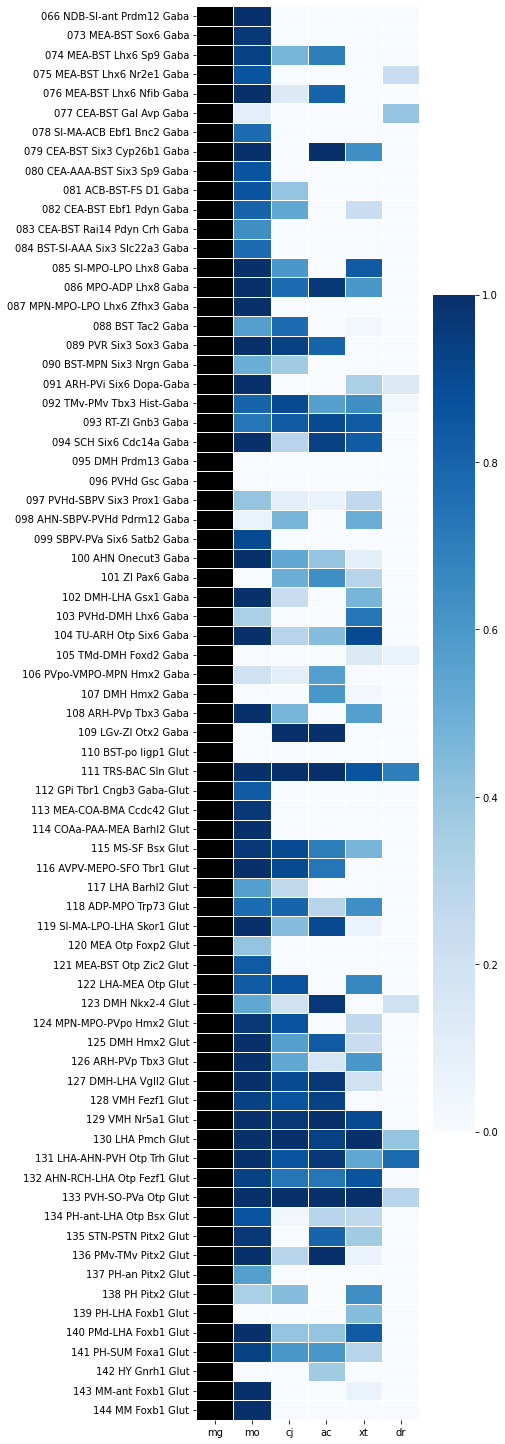

In [64]:
plt.figure(figsize=(5, 26))
ax = sns.heatmap(plt_df_saturn,cmap = 'Blues',linewidth = .5)
ax.set_facecolor('black')
plt.savefig('../../Figures/Figures_07242026/Mapped_CT_mousefrac_saturn_Heatmap_boot_07272026.svg',bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_07242026/mapped_CT_mousefrac_saturn_Heatmap_boot_07272026.png', bbox_inches = 'tight',dpi = 300)
plt.savefig('../../Figures/Figures_07242026/Mapped_CT_mousefrac_saturn_Heatmap_boot_07272026.pdf',bbox_inches = 'tight')

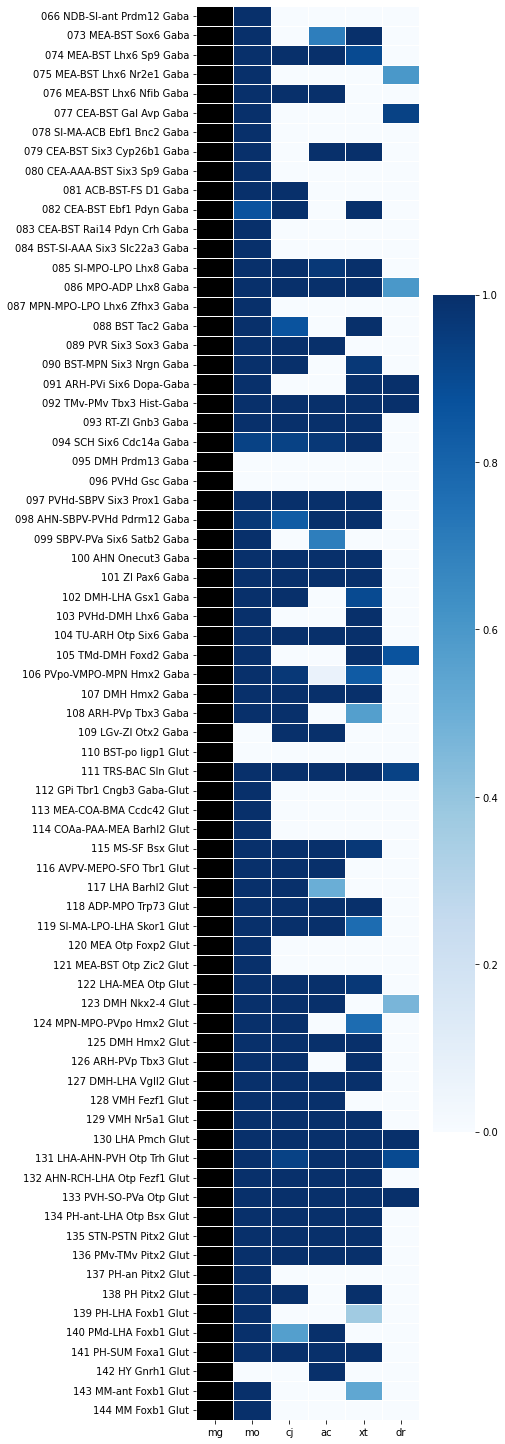

In [65]:
plt.figure(figsize=(5, 26),facecolor='white')
ax = sns.heatmap(plt_df_samap, cmap = 'Blues',linewidth = .5)
ax.set_facecolor('black')
plt.savefig('../../Figures/Figures_07242026/Mapped_CT_mousefrac_samap_Heatmap_boot_07272026.svg',bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_07242026/mapped_CT_mousefrac_samap_Heatmap_boot_07272026.png', bbox_inches = 'tight',dpi = 300)
plt.savefig('../../Figures/Figures_07242026/Mapped_CT_mousefrac_samap_Heatmap_boot_07272026.pdf',bbox_inches = 'tight')

In [81]:
plt_df_saturn.to_csv('SATURN_mousemapping_allorgs_07272026.csv')
plt_df_samap.to_csv('SAMAP_mousemapping_allorgs_07272026.csv')

In [ ]:
######Figure 2B

In [10]:
plt_df_samap = pd.read_csv('../../SAMAP_mousemapping_allorgs_07272026.csv',index_col ='Unnamed: 0')

In [11]:
MO_NT = pd.read_csv('../../NT/08042026/MO.nt.type.csv', index_col = 'subclass')
CJ_NT = pd.read_csv('../../NT/08042026/CJ.nt.type.csv', index_col = 'subclass')
AC_NT = pd.read_csv('../../NT/08042026/AC.nt.type.csv', index_col = 'subclass')
XT_NT = pd.read_csv('../../NT/08042026/XT.nt.type.csv', index_col = 'subclass')
DR_NT = pd.read_csv('../../NT/08042026/DR.nt.type.csv', index_col = 'subclass')

In [12]:
for org in plt_df_NT.columns:
    for ct in plt_df_NT.index:
        if org =='mg':
            plt_df_NT.loc[ct, org] = ct.split(' ')[-1]
        elif plt_df_samap.loc[ct,org] > 0:
            if org == 'mo':
                plt_df_NT.loc[ct,org] = MO_NT.loc[ct,'Neurotransmitter']
            elif org == 'cj':
                plt_df_NT.loc[ct,org] = CJ_NT.loc[ct,'Neurotransmitter']
            elif org == 'ac':
                plt_df_NT.loc[ct,org] = AC_NT.loc[ct,'Neurotransmitter']
            elif org == 'xt':
                plt_df_NT.loc[ct,org] = XT_NT.loc[ct,'Neurotransmitter']
            elif org == 'dr':
                plt_df_NT.loc[ct,org] = DR_NT.loc[ct,'Neurotransmitter']
            else:
                print('error')

In [13]:
index_sort = list(plt_df_samap.index)
index_sort.sort()

In [14]:
plt_df_NT = plt_df_NT.reindex(index_sort)

In [15]:
nt_mapping = {'Gaba-Chol':1,
             'Chol':1,
             'Glut-Chol':1,
             'Glut-Gaba-Dopa':2,
             'Gaba-Dopa':2,
             'Dopa-Gaba':2,
             'Glut-Dopa':2,
             'Dopa':2,
             'Gly':3,
             'Hist':4,
             'Gaba':5,
             'Glut':6,
             'Gaba-Glut':7,
             'Glut-Gaba':7,
             'Gaba-Gly':3,
             'Glut-Gly': 3,
             'Glut-Gaba-Gly':3,
             'Gaba-Hist':4,
             'Hist-Gaba':4,
             'Nora':8,
             'Gaba-Sert':9,
             'Glut-Sert':9,
             'unclear':10,
             'Chol-Gly':11,
             'Sert':9,
             'Glut-Sert-Gly':12,
             'Gaba-Dopa-Sert':9,
             'Glut-Gaba-Hist':4,
             'Glut-Gaba-Sert-Hist':4}

In [16]:
NT_df_numeric = plt_df_NT.replace(nt_mapping)

In [17]:
NT_df_numeric = NT_df_numeric.reindex(index_sort)

In [18]:
custom_colors = ['#73E785','#FCF04B','#820E57','#FF7621','#FF3358','#2B93DF','#0A9964','#03EDFF','#4f2e91ff','black','pink','salmon','maroon','goldenrod']

In [19]:
custom_cmap = LinearSegmentedColormap.from_list('Custom', custom_colors, len(custom_colors))

In [20]:
NT_df_numeric

,mg,mo,cj,ac,xt,dr
066 NDB-SI-ant Prdm12 Gaba,5,5.0,NaN,NaN,NaN,NaN
073 MEA-BST Sox6 Gaba,5,5.0,NaN,5.0,5.0,NaN
074 MEA-BST Lhx6 Sp9 Gaba,5,5.0,5.0,5.0,5.0,NaN
075 MEA-BST Lhx6 Nr2e1 Gaba,5,5.0,NaN,NaN,NaN,5.0
076 MEA-BST Lhx6 Nfib Gaba,5,5.0,5.0,5.0,NaN,NaN
...,...,...,...,...,...,...
140 PMd-LHA Foxb1 Glut,6,6.0,6.0,6.0,NaN,NaN
141 PH-SUM Foxa1 Glut,6,6.0,6.0,6.0,6.0,NaN
142 HY Gnrh1 Glut,6,NaN,NaN,6.0,NaN,NaN
143 MM-ant Foxb1 Glut,6,6.0,NaN,NaN,6.0,NaN


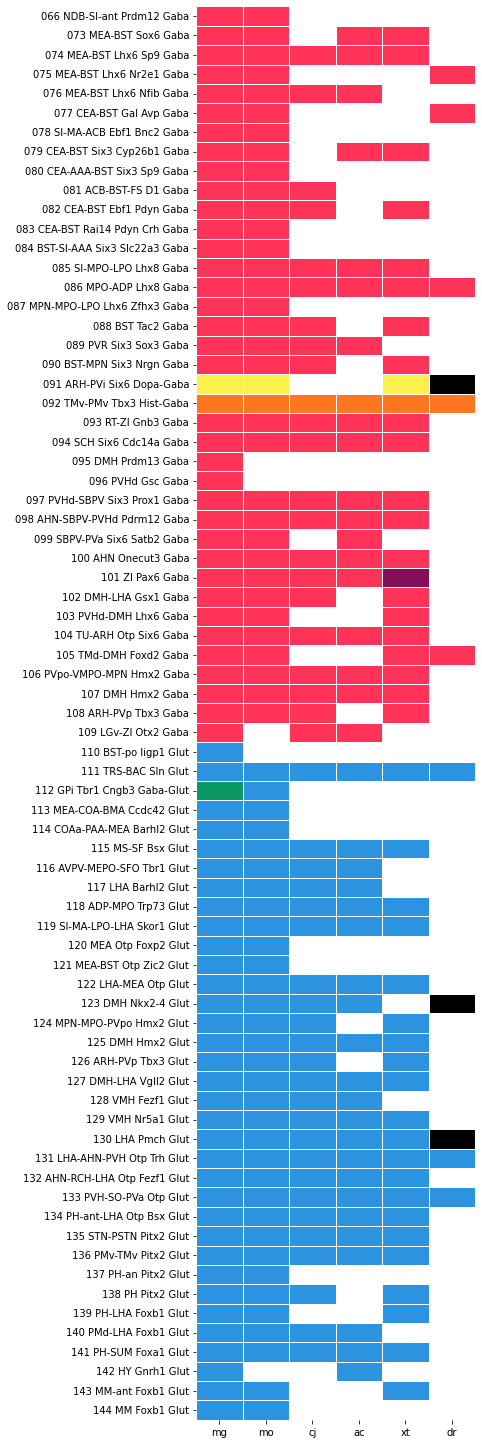

In [21]:
plt.figure(figsize=(5, 26))
ax = sns.heatmap(NT_df_numeric,cmap=custom_cmap, vmax = 14, vmin = 1, cbar = False, linewidth = .5)
plt.savefig('../../Figures/Figures_08022026/Nonmam_mapping_NT_08042026.svg',bbox_inches='tight')
plt.savefig('../../Figures/Figures_08022026/Nonmam_mapping_NT_08042026.png',bbox_inches='tight',dpi=300)
plt.savefig('../../Figures/Figures_08022026/Nonmam_mapping_NT_08042026.pdf',bbox_inches='tight')

In [22]:
NT_df_numeric.to_csv('../../NT_mapping_allorgs_08042026.csv')

In [ ]:
#Numcells plotting

In [2]:
df = pd.read_csv('../../Allen_Institute_Numcells_RegionHY_04072026.csv')

In [7]:
HYPO = [i for i in df['cell_type'].unique() if parent_dict[parent_dict[i]] == 'hypo']

In [8]:
dfhypo = df[df['cell_type'].isin(HYPO)]

In [9]:
dfhypo = dfhypo.sort_values('cell_type')

In [11]:
dfhypo[dfhypo['cell_type'] == '120 MEA Otp Foxp2 Glut']

,Unnamed: 0,Unnamed: 0.1,cell_type,count,fraction
132,132,132,120 MEA Otp Foxp2 Glut,4,0.000022


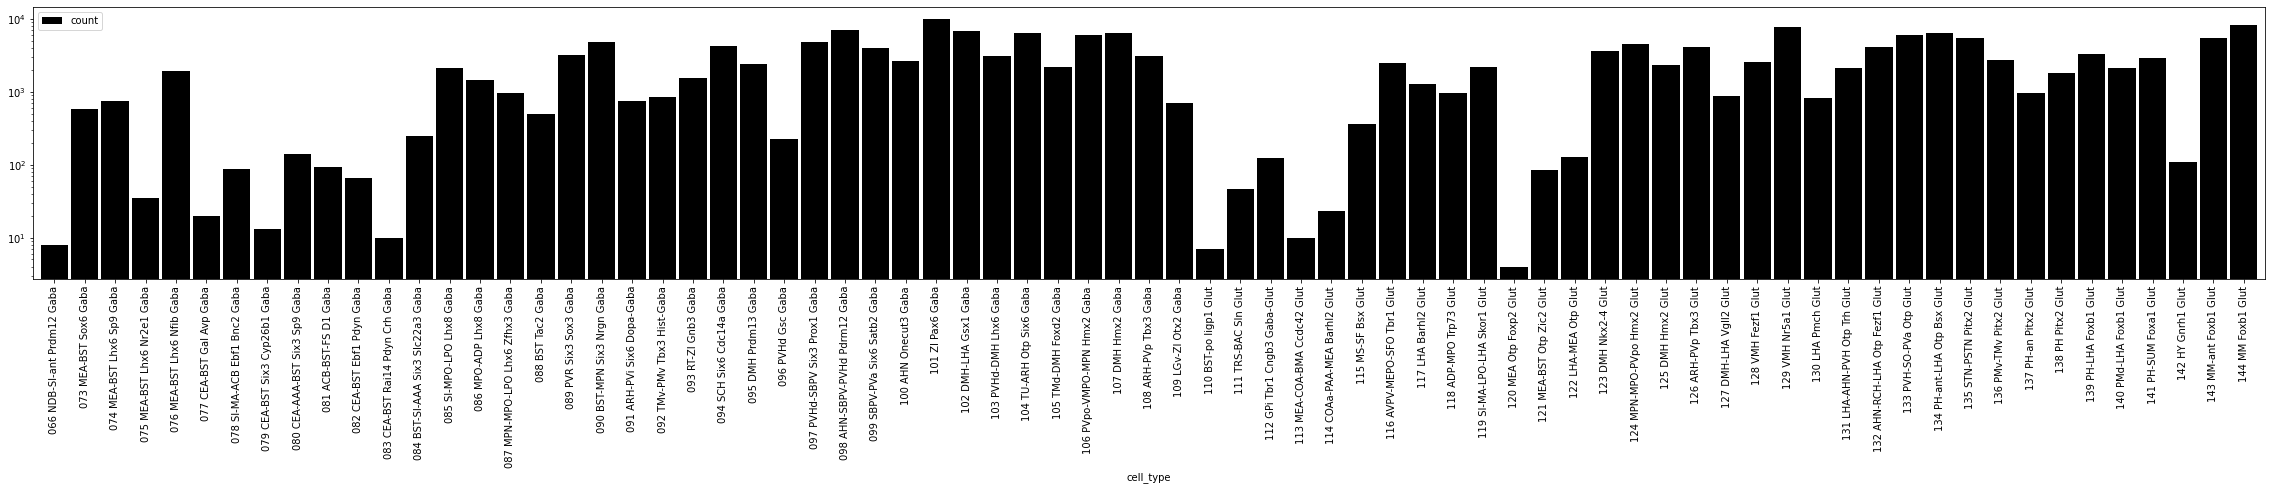

In [32]:
dfhypo.plot(kind='bar', x = 'cell_type',y='count', width = .9,color = 'black',figsize=(40,5))
plt.yscale('log')
plt.savefig('Figures/Figures_04102026/Numcells_CT_updated_04072026.png', bbox_inches = 'tight', dpi = 300)
plt.savefig('Figures/Figures_04102026/Numcells_CT_updated_04072026.svg')

In [34]:
df['fraction'] = df['count']/np.sum(df['count'])

In [14]:
mam_ct = ['066 NDB-SI-ant Prdm12 Gaba',
 '078 SI-MA-ACB Ebf1 Bnc2 Gaba',
 '080 CEA-AAA-BST Six3 Sp9 Gaba',
 '083 CEA-BST Rai14 Pdyn Crh Gaba',
 '084 BST-SI-AAA Six3 Slc22a3 Gaba',
 '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
 '112 GPi Tbr1 Cngb3 Gaba-Glut',
 '113 MEA-COA-BMA Ccdc42 Glut',
 '114 COAa-PAA-MEA Barhl2 Glut',
 '120 MEA Otp Foxp2 Glut',
 '121 MEA-BST Otp Zic2 Glut',
 '137 PH-an Pitx2 Glut',
 '144 MM Foxb1 Glut']

In [19]:
for item in mam_ct:
    if df[df['cell_type'] == item]['fraction'].values > 0.001:
        print(item)

084 BST-SI-AAA Six3 Slc22a3 Gaba
087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba
137 PH-an Pitx2 Glut
144 MM Foxb1 Glut
